# BMR & TDEE Analysis

| # | Pertanyaan Bisnis | Relevansi ke Fitur |
|---|---|---|
| Q1 | Bagaimana BMR bervariasi berdasarkan gender & usia? | Justify kenapa form input butuh data umur & gender |
| Q2 | Seberapa besar pengaruh tingkat aktivitas terhadap TDEE? | Justify kenapa input aktivitas wajib ada di form |
| Q3 | Bagaimana distribusi makronutrien ideal per tujuan diet? | Dasar kalkulasi output dashboard (Fitur 5) |
| Q4 | Seperti apa output yang diterima user dari profil nyata? | Validasi end-to-end pipeline Fitur 4 → Fitur 5 |

**Formula:** Mifflin-St Jeor
```
BMR Pria   = (10 × berat_kg) + (6.25 × tinggi_cm) − (5 × usia) + 5
BMR Wanita = (10 × berat_kg) + (6.25 × tinggi_cm) − (5 × usia) − 161
TDEE       = BMR × Activity Factor
```

## Setup & Formula Implementasi

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'axes.grid.axis': 'y',
    'grid.alpha': 0.25,
    'grid.linestyle': '--',
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.titlepad': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
})

C = {
    'pria':    '#185FA5',
    'wanita':  '#D85A30',
    'cut':     '#1D9E75',
    'maintain':'#185FA5',
    'bulk':    '#D85A30',
    'neutral': '#888780',
    'bg':      '#F8F7F3',
    'protein': '#185FA5',
    'karbo':   '#E9C46A',
    'lemak':   '#D85A30',
}

# ── Formula Mifflin-St Jeor ──
def hitung_bmr(berat_kg: float, tinggi_cm: float, usia: int, gender: str) -> float:
    """
    Menghitung BMR menggunakan formula Mifflin-St Jeor (1990).
    Parameter:
        berat_kg  : berat badan dalam kilogram
        tinggi_cm : tinggi badan dalam sentimeter
        usia      : usia dalam tahun
        gender    : 'pria' atau 'wanita'
    Returns:
        BMR dalam kcal/hari
    """
    base = (10 * berat_kg) + (6.25 * tinggi_cm) - (5 * usia)
    return base + 5 if gender == 'pria' else base - 161


# ── Activity Factor (PAL) ──
AKTIVITAS = {
    'Sedentary\n(tidak olahraga)':       1.200,
    'Lightly active\n(1-3x/minggu)':     1.375,
    'Moderately active\n(3-5x/minggu)':  1.550,
    'Very active\n(6-7x/minggu)':        1.725,
    'Extra active\n(atlet/kerja fisik)': 1.900,
}

def hitung_tdee(bmr: float, aktivitas_label: str) -> float:
    """Menghitung TDEE = BMR × Activity Factor."""
    return bmr * AKTIVITAS[aktivitas_label]


# ── Distribusi Makronutrien per Tujuan Diet ──
TUJUAN = {
    'Cut\n(Defisit -20%)':  {'mult': 0.80, 'protein': 0.35, 'karbo': 0.35, 'lemak': 0.30},
    'Maintain\n(Balance)':  {'mult': 1.00, 'protein': 0.30, 'karbo': 0.40, 'lemak': 0.30},
    'Bulk\n(Surplus +15%)': {'mult': 1.15, 'protein': 0.25, 'karbo': 0.50, 'lemak': 0.25},
}

def hitung_makro(tdee: float, tujuan_label: str) -> dict:
    """Menghitung gram makronutrien dari TDEE dan tujuan diet."""
    cfg = TUJUAN[tujuan_label]
    kal = tdee * cfg['mult']
    return {
        'kalori_target': round(kal),
        'protein_g':     round(kal * cfg['protein'] / 4),
        'karbo_g':       round(kal * cfg['karbo']   / 4),
        'lemak_g':       round(kal * cfg['lemak']   / 9),
    }

print('✅ Formula Mifflin-St Jeor siap')
print(f"   Contoh: Pria 25th, 70kg, 170cm → BMR = {hitung_bmr(70, 170, 25, 'pria'):.0f} kcal/hari")
print(f"   Contoh: Wanita 25th, 60kg, 160cm → BMR = {hitung_bmr(60, 160, 25, 'wanita'):.0f} kcal/hari")

✅ Formula Mifflin-St Jeor siap
   Contoh: Pria 25th, 70kg, 170cm → BMR = 1642 kcal/hari
   Contoh: Wanita 25th, 60kg, 160cm → BMR = 1314 kcal/hari


---
## Q1 - Bagaimana BMR bervariasi berdasarkan gender & usia?



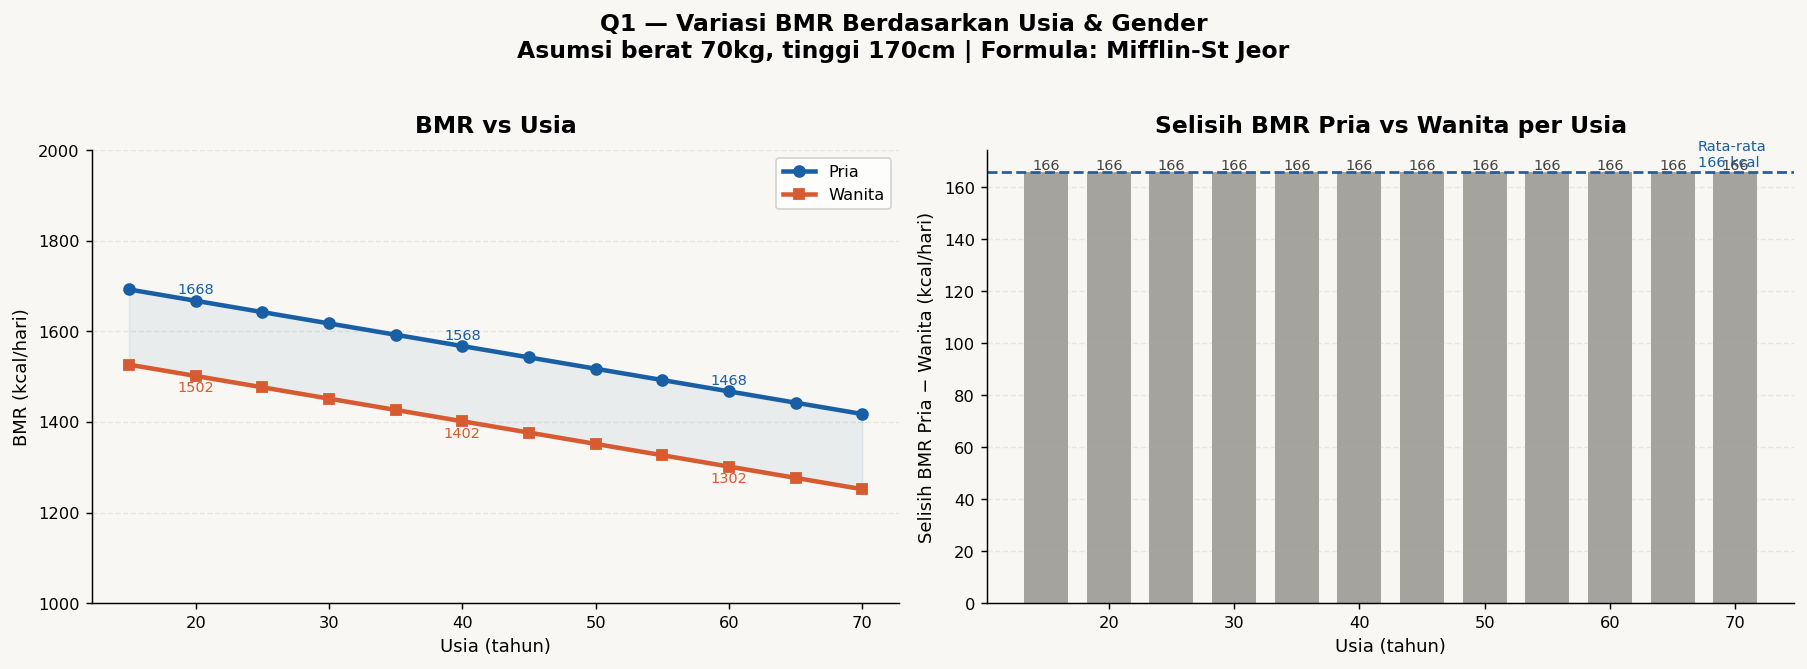

In [3]:
# Generate data BMR untuk berbagai kombinasi usia & gender
BERAT_REF, TINGGI_REF = 70, 170

rows = []
for usia in range(15, 71, 5):
    rows.append({'Usia': usia, 'Gender': 'Pria',   'BMR': hitung_bmr(BERAT_REF, TINGGI_REF, usia, 'pria')})
    rows.append({'Usia': usia, 'Gender': 'Wanita', 'BMR': hitung_bmr(BERAT_REF, TINGGI_REF, usia, 'wanita')})
df_q1 = pd.DataFrame(rows)

pria   = df_q1[df_q1['Gender'] == 'Pria']
wanita = df_q1[df_q1['Gender'] == 'Wanita']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor(C['bg'])
fig.suptitle(
    'Q1 — Variasi BMR Berdasarkan Usia & Gender\n'
    f'Asumsi berat {BERAT_REF}kg, tinggi {TINGGI_REF}cm | Formula: Mifflin-St Jeor',
    fontsize=13, fontweight='bold', y=1.02
)

# Plot 1 — Line chart BMR vs usia
ax = axes[0]
ax.set_facecolor(C['bg'])
ax.plot(pria['Usia'],   pria['BMR'],   'o-', color=C['pria'],   lw=2.5, ms=6, label='Pria')
ax.plot(wanita['Usia'], wanita['BMR'], 's-', color=C['wanita'], lw=2.5, ms=6, label='Wanita')
ax.fill_between(pria['Usia'], pria['BMR'], wanita['BMR'], alpha=0.07, color=C['pria'])
for _, row in pria[pria['Usia'].isin([20, 40, 60])].iterrows():
    ax.annotate(f"{row['BMR']:.0f}", (row['Usia'], row['BMR']+15), ha='center', fontsize=8, color=C['pria'])
for _, row in wanita[wanita['Usia'].isin([20, 40, 60])].iterrows():
    ax.annotate(f"{row['BMR']:.0f}", (row['Usia'], row['BMR']-35), ha='center', fontsize=8, color=C['wanita'])
ax.set_xlabel('Usia (tahun)')
ax.set_ylabel('BMR (kcal/hari)')
ax.set_title('BMR vs Usia', pad=10)
ax.legend(fontsize=9)
ax.set_ylim(1000, 2000)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Plot 2 — Bar gap pria vs wanita per usia (selisih)
ax2 = axes[1]
ax2.set_facecolor(C['bg'])
selisih = pria['BMR'].values - wanita['BMR'].values
bars = ax2.bar(pria['Usia'], selisih, width=3.5, color=C['neutral'], alpha=0.75)
ax2.axhline(selisih.mean(), color=C['pria'], lw=1.5, ls='--')
ax2.text(67, selisih.mean()+2, f'Rata-rata\n{selisih.mean():.0f} kcal', fontsize=8, color=C['pria'])
for bar, val in zip(bars, selisih):
    ax2.text(bar.get_x()+bar.get_width()/2, val+1, f'{val:.0f}', ha='center', fontsize=8, color='#444')
ax2.set_xlabel('Usia (tahun)')
ax2.set_ylabel('Selisih BMR Pria − Wanita (kcal/hari)')
ax2.set_title('Selisih BMR Pria vs Wanita per Usia', pad=10)
ax2.grid(axis='y', alpha=0.25, linestyle='--')

plt.tight_layout()
plt.savefig('chart_q1_bmr_gender_usia.png', bbox_inches='tight', facecolor=C['bg'])
plt.show()

**Insight:**
- BMR menurun ~50 kcal setiap 10 tahun — artinya **usia adalah input wajib** yang tidak bisa diestimasi
- Pria memiliki BMR rata-rata **166 kcal lebih tinggi** dari wanita dengan berat & tinggi yang sama (konstanta Mifflin: +5 vs −161)
- Selisih ini **konstan** terlepas dari usia → gender wajib jadi field terpisah di Form Profil User



---
## Q2 - Seberapa besar pengaruh tingkat aktivitas terhadap TDEE?



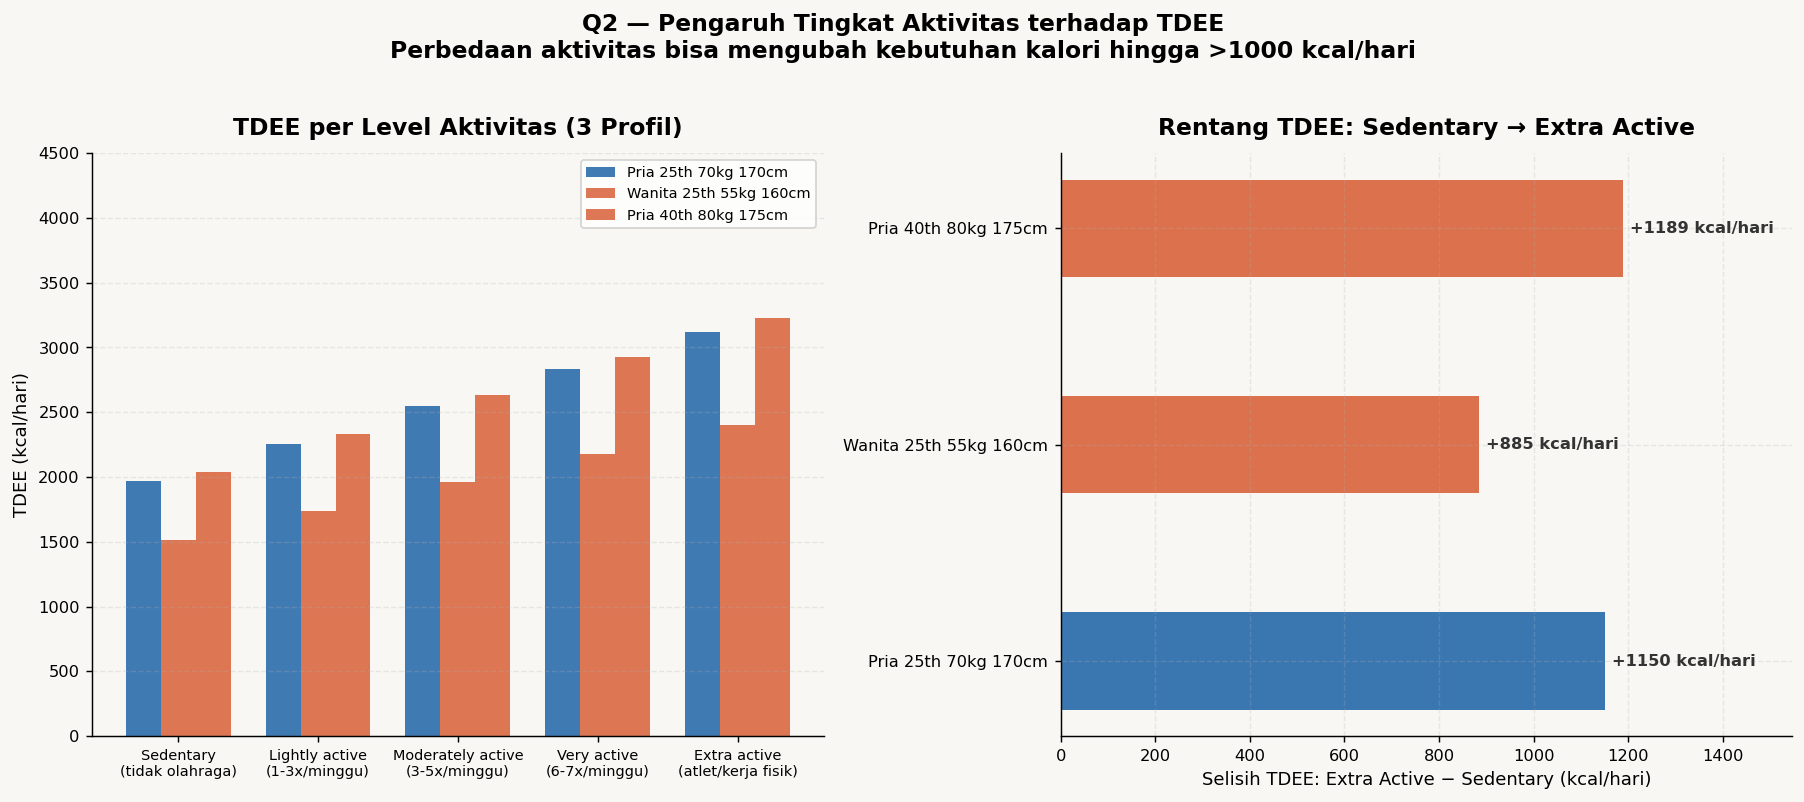

In [4]:
# Simulasi TDEE untuk 3 profil representatif × 5 level aktivitas
PROFIL_Q2 = [
    {'label': 'Pria 25th\n70kg 170cm',   'bmr': hitung_bmr(70, 170, 25, 'pria')},
    {'label': 'Wanita 25th\n55kg 160cm', 'bmr': hitung_bmr(55, 160, 25, 'wanita')},
    {'label': 'Pria 40th\n80kg 175cm',   'bmr': hitung_bmr(80, 175, 40, 'pria')},
]

akt_labels = list(AKTIVITAS.keys())
akt_values = list(AKTIVITAS.values())

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor(C['bg'])
fig.suptitle(
    'Q2 — Pengaruh Tingkat Aktivitas terhadap TDEE\n'
    'Perbedaan aktivitas bisa mengubah kebutuhan kalori hingga >1000 kcal/hari',
    fontsize=13, fontweight='bold', y=1.02
)

# Plot 1 - grouped bar: TDEE per level aktivitas per profil
ax = axes[0]
ax.set_facecolor(C['bg'])
x = np.arange(len(akt_labels))
w = 0.25
colors_profil = [C['pria'], C['wanita'], C['bulk']]
for i, profil in enumerate(PROFIL_Q2):
    tdees = [profil['bmr'] * f for f in akt_values]
    bars = ax.bar(x + i*w, tdees, w, label=profil['label'].replace('\n', ' '),
                  color=colors_profil[i], alpha=0.82)
ax.set_xticks(x + w)
ax.set_xticklabels([l.replace('\n', '\n') for l in akt_labels], fontsize=8)
ax.set_ylabel('TDEE (kcal/hari)')
ax.set_title('TDEE per Level Aktivitas (3 Profil)', pad=10)
ax.legend(fontsize=8)
ax.set_ylim(0, 4500)
ax.grid(axis='y', alpha=0.25, linestyle='--')

# Plot 2 - delta TDEE: selisih sedentary vs extra active
ax2 = axes[1]
ax2.set_facecolor(C['bg'])
deltas = [(p['bmr'] * 1.9) - (p['bmr'] * 1.2) for p in PROFIL_Q2]
labels_profil = [p['label'].replace('\n', ' ') for p in PROFIL_Q2]
bars2 = ax2.barh(labels_profil, deltas, color=colors_profil, height=0.45, alpha=0.85)
for bar, val in zip(bars2, deltas):
    ax2.text(val + 15, bar.get_y() + bar.get_height()/2,
             f'+{val:.0f} kcal/hari', va='center', fontsize=9, fontweight='bold', color='#333')
ax2.set_xlabel('Selisih TDEE: Extra Active − Sedentary (kcal/hari)')
ax2.set_title('Rentang TDEE: Sedentary → Extra Active', pad=10)
ax2.grid(axis='x', alpha=0.25, linestyle='--')
ax2.set_xlim(0, max(deltas) * 1.3)

plt.tight_layout()
plt.savefig('chart_q2_aktivitas_tdee.png', bbox_inches='tight', facecolor=C['bg'])
plt.show()

**Insight:**
- Perbedaan antara Sedentary dan Extra Active menghasilkan selisih TDEE **+1.000–1.300 kcal/hari** tergantung profil
- Ini setara dengan 1–2 kali makan penuh - kesalahan input aktivitas bisa membuat rekomendasi kalori **meleset jauh**
- Activity Factor bukan variabel minor: kontribusinya terhadap total TDEE berkisar **20–58%** di atas BMR



---
## Q3 - Bagaimana distribusi makronutrien ideal per tujuan diet?



Profil demo: Pria 25th 70kg 170cm, Moderately active
BMR = 1642 kcal | TDEE = 2546 kcal
  Cut (Defisit -20%): 2037 kcal | P=178g K=178g L=68g
  Maintain (Balance): 2546 kcal | P=191g K=255g L=85g
  Bulk (Surplus +15%): 2928 kcal | P=183g K=366g L=81g


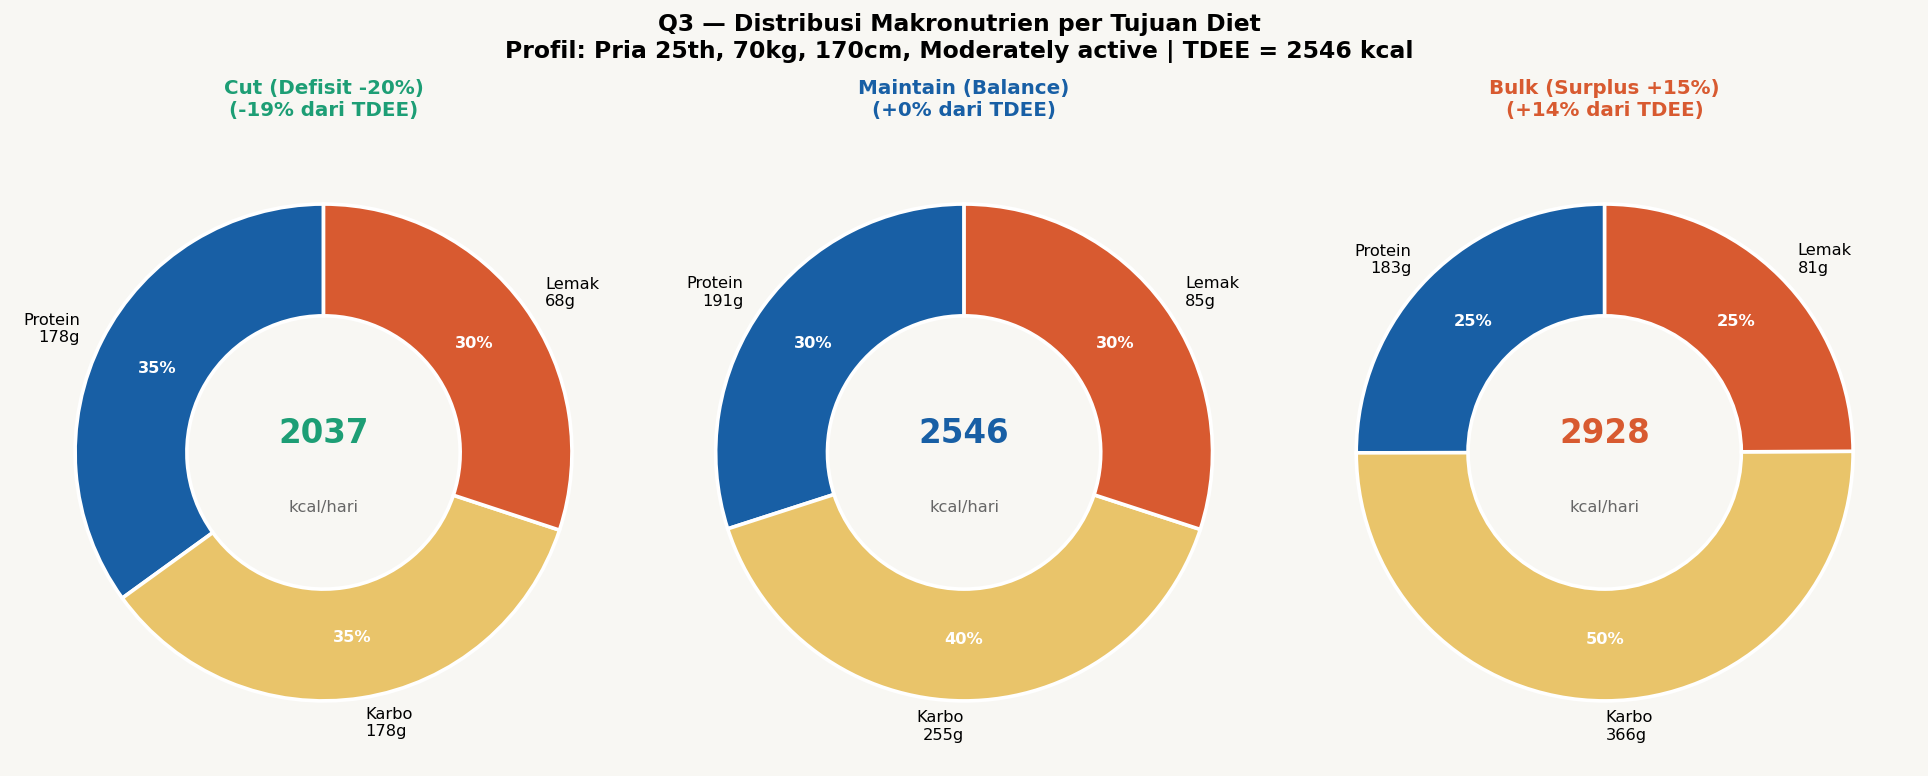

In [5]:
# Demonstrasi distribusi makro untuk TDEE representatif
BMR_DEMO  = hitung_bmr(70, 170, 25, 'pria')
TDEE_DEMO = BMR_DEMO * AKTIVITAS['Moderately active\n(3-5x/minggu)']
print(f'Profil demo: Pria 25th 70kg 170cm, Moderately active')
print(f'BMR = {BMR_DEMO:.0f} kcal | TDEE = {TDEE_DEMO:.0f} kcal')

tujuan_labels = list(TUJUAN.keys())
makro_data = {t: hitung_makro(TDEE_DEMO, t) for t in tujuan_labels}
for t, m in makro_data.items():
    print(f"  {t.replace(chr(10),' ')}: {m['kalori_target']} kcal | "
          f"P={m['protein_g']}g K={m['karbo_g']}g L={m['lemak_g']}g")

fig, axes = plt.subplots(1, 3, figsize=(15, 6))
fig.patch.set_facecolor(C['bg'])
fig.suptitle(
    'Q3 — Distribusi Makronutrien per Tujuan Diet\n'
    f'Profil: Pria 25th, 70kg, 170cm, Moderately active | TDEE = {TDEE_DEMO:.0f} kcal',
    fontsize=13, fontweight='bold', y=1.02
)

tujuan_colors = [C['cut'], C['maintain'], C['bulk']]
for i, (tujuan, color) in enumerate(zip(tujuan_labels, tujuan_colors)):
    ax = axes[i]
    ax.set_facecolor(C['bg'])
    m = makro_data[tujuan]
    cfg = TUJUAN[tujuan]

    # Donut chart
    vals  = [m['protein_g'] * 4, m['karbo_g'] * 4, m['lemak_g'] * 9]
    clrs  = [C['protein'], C['karbo'], C['lemak']]
    lbls  = [f"Protein\n{m['protein_g']}g", f"Karbo\n{m['karbo_g']}g", f"Lemak\n{m['lemak_g']}g"]
    wedge_props = dict(width=0.45, edgecolor='white', linewidth=2)
    wedges, texts, autotexts = ax.pie(
        vals, labels=lbls, colors=clrs,
        autopct='%1.0f%%', startangle=90,
        wedgeprops=wedge_props, pctdistance=0.75,
        textprops={'fontsize': 9}
    )
    for at in autotexts:
        at.set_fontsize(9)
        at.set_fontweight('bold')
        at.set_color('white')

    # Center text
    ax.text(0, 0.08, f"{m['kalori_target']}", ha='center', va='center',
            fontsize=18, fontweight='bold', color=color)
    ax.text(0, -0.22, 'kcal/hari', ha='center', va='center', fontsize=9, color='#666')
    deficit_txt = f"({int((cfg['mult']-1)*100):+.0f}% dari TDEE)"
    ax.set_title(f"{tujuan.replace(chr(10), ' ')}\n{deficit_txt}", fontsize=11, fontweight='bold',
                pad=15, color=color)

plt.tight_layout()
plt.savefig('chart_q3_distribusi_makro.png', bbox_inches='tight', facecolor=C['bg'])
plt.show()

**Insight:**
- **Cut (−20%):** Protein diperbesar ke 35% untuk mencegah muscle loss saat defisit kalori
- **Maintain:** Distribusi seimbang 30/40/30 - standar WHO untuk diet sehat umum
- **Bulk (+15%):** Karbohidrat dinaikkan ke 50% untuk mendukung energi latihan dan sintesis glikogen otot
- Perubahan tujuan diet **tidak hanya mengubah total kalori** tapi juga komposisi makronya



---
## Q4 - Simulasi End-to-End: Profil User → Output BMR/TDEE/Makro



In [6]:
# 3 profil user representatif
PROFIL_USERS = [
    {'nama': 'Andi', 'deskripsi': 'Pria 22th · 70kg · 170cm',
     'berat': 70, 'tinggi': 170, 'usia': 22, 'gender': 'pria',
     'aktivitas': 'Moderately active\n(3-5x/minggu)', 'tujuan': 'Maintain\n(Balance)'},
    {'nama': 'Sari', 'deskripsi': 'Wanita 28th · 55kg · 160cm',
     'berat': 55, 'tinggi': 160, 'usia': 28, 'gender': 'wanita',
     'aktivitas': 'Lightly active\n(1-3x/minggu)', 'tujuan': 'Cut\n(Defisit -20%)'},
    {'nama': 'Budi', 'deskripsi': 'Pria 35th · 85kg · 175cm',
     'berat': 85, 'tinggi': 175, 'usia': 35, 'gender': 'pria',
     'aktivitas': 'Very active\n(6-7x/minggu)', 'tujuan': 'Bulk\n(Surplus +15%)'},
]

# Hitung semua
hasil = []
for p in PROFIL_USERS:
    bmr  = hitung_bmr(p['berat'], p['tinggi'], p['usia'], p['gender'])
    tdee = hitung_tdee(bmr, p['aktivitas'])
    makro = hitung_makro(tdee, p['tujuan'])
    hasil.append({**p, 'bmr': bmr, 'tdee': tdee, **makro})

# Print summary tabel
print('=' * 70)
print('  HASIL KALKULASI FITUR 4 — SIMULASI 3 PROFIL USER')
print('=' * 70)
for h in hasil:
    print(f"\n👤 {h['nama']} ({h['deskripsi']})")
    print(f"   Tujuan : {h['tujuan'].replace(chr(10), ' ')}")
    print(f"   Aktivitas: {h['aktivitas'].replace(chr(10), ' ')}")
    print(f"   ─────────────────────────────")
    print(f"   BMR            : {h['bmr']:.0f} kcal/hari")
    print(f"   TDEE           : {h['tdee']:.0f} kcal/hari")
    print(f"   Kalori Target  : {h['kalori_target']} kcal/hari")
    print(f"   Protein        : {h['protein_g']}g/hari")
    print(f"   Karbohidrat    : {h['karbo_g']}g/hari")
    print(f"   Lemak          : {h['lemak_g']}g/hari")

  HASIL KALKULASI FITUR 4 — SIMULASI 3 PROFIL USER

👤 Andi (Pria 22th · 70kg · 170cm)
   Tujuan : Maintain (Balance)
   Aktivitas: Moderately active (3-5x/minggu)
   ─────────────────────────────
   BMR            : 1658 kcal/hari
   TDEE           : 2569 kcal/hari
   Kalori Target  : 2569 kcal/hari
   Protein        : 193g/hari
   Karbohidrat    : 257g/hari
   Lemak          : 86g/hari

👤 Sari (Wanita 28th · 55kg · 160cm)
   Tujuan : Cut (Defisit -20%)
   Aktivitas: Lightly active (1-3x/minggu)
   ─────────────────────────────
   BMR            : 1249 kcal/hari
   TDEE           : 1717 kcal/hari
   Kalori Target  : 1374 kcal/hari
   Protein        : 120g/hari
   Karbohidrat    : 120g/hari
   Lemak          : 46g/hari

👤 Budi (Pria 35th · 85kg · 175cm)
   Tujuan : Bulk (Surplus +15%)
   Aktivitas: Very active (6-7x/minggu)
   ─────────────────────────────
   BMR            : 1774 kcal/hari
   TDEE           : 3060 kcal/hari
   Kalori Target  : 3519 kcal/hari
   Protein        : 220g/ha

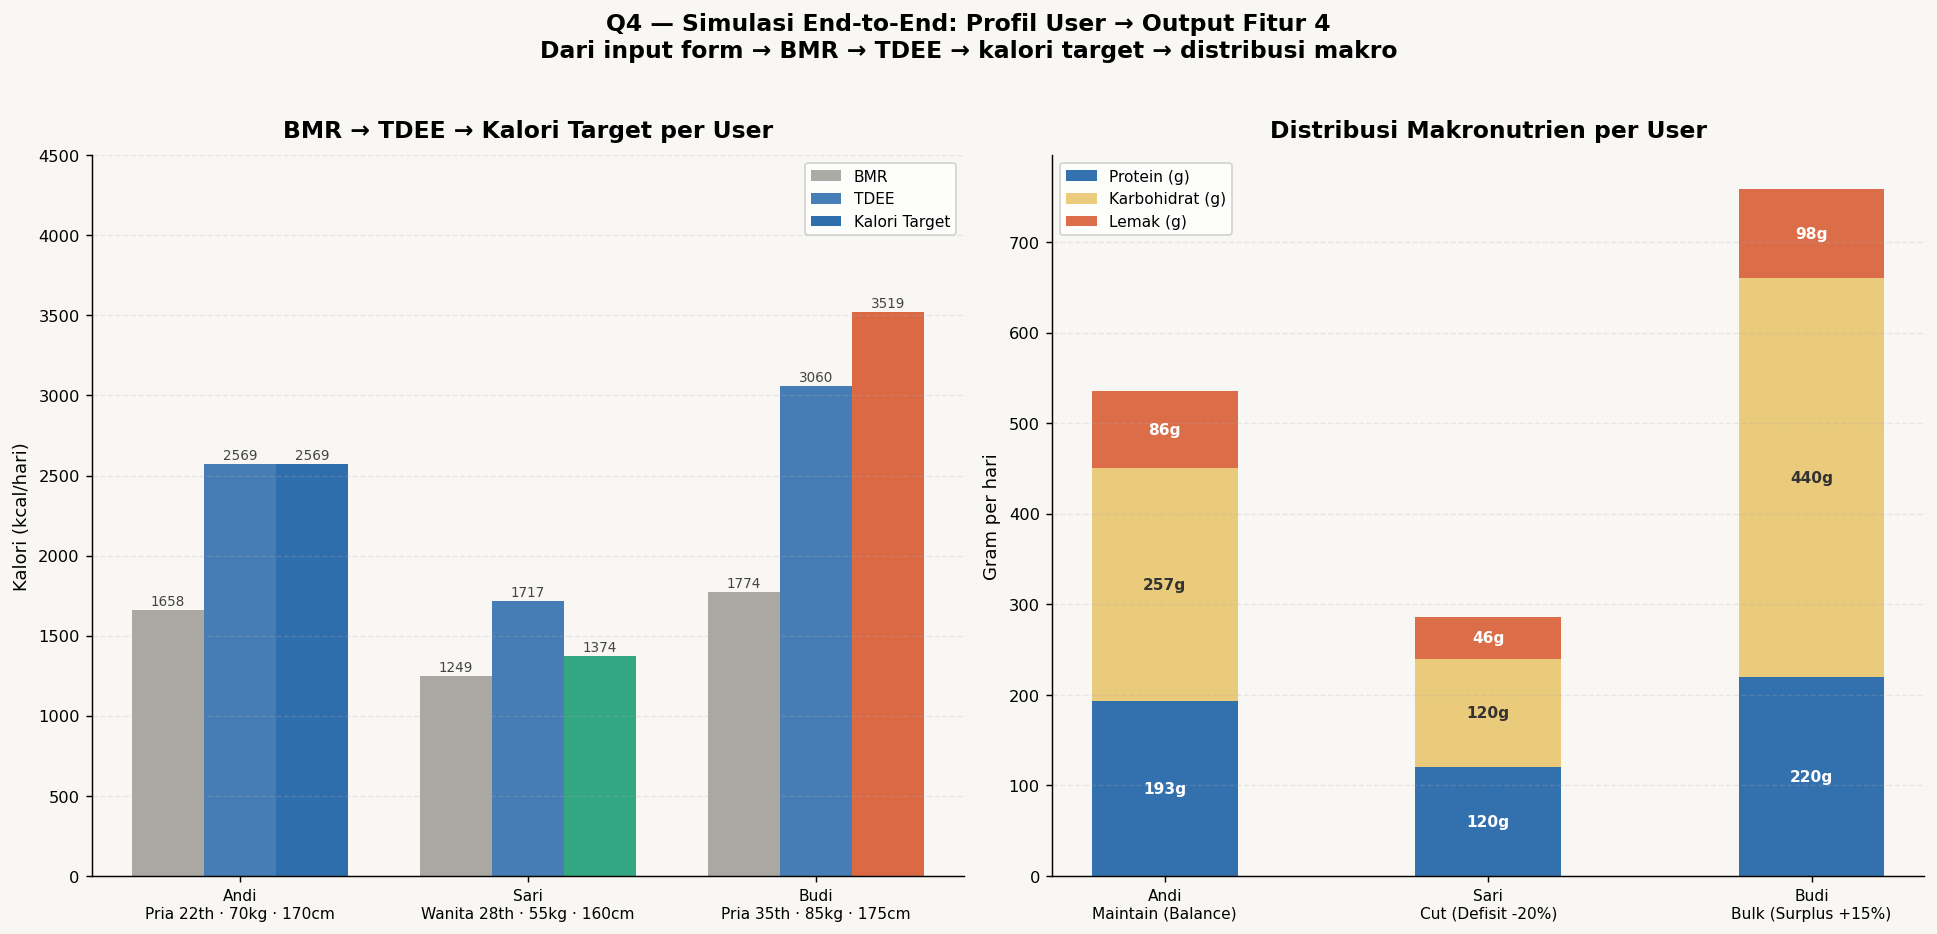

In [7]:
# Visualisasi simulasi — stacked bar kalori target + breakdown makro
fig, axes = plt.subplots(1, 2, figsize=(15, 7))
fig.patch.set_facecolor(C['bg'])
fig.suptitle(
    'Q4 — Simulasi End-to-End: Profil User → Output Fitur 4\n'
    'Dari input form → BMR → TDEE → kalori target → distribusi makro',
    fontsize=13, fontweight='bold', y=1.02
)

nama_labels = [h['nama'] for h in hasil]
tujuan_colors_map = {
    'Cut\n(Defisit -20%)':  C['cut'],
    'Maintain\n(Balance)':  C['maintain'],
    'Bulk\n(Surplus +15%)': C['bulk'],
}

# Plot 1 — BMR vs TDEE vs Kalori Target per user
ax = axes[0]
ax.set_facecolor(C['bg'])
x = np.arange(len(hasil))
w = 0.25
b1 = ax.bar(x - w, [h['bmr'] for h in hasil],            w, label='BMR',           color=C['neutral'], alpha=0.7)
b2 = ax.bar(x,     [h['tdee'] for h in hasil],           w, label='TDEE',          color=C['pria'],    alpha=0.8)
b3 = ax.bar(x + w, [h['kalori_target'] for h in hasil],  w, label='Kalori Target', alpha=0.9,
            color=[tujuan_colors_map[h['tujuan']] for h in hasil])
for bars in [b1, b2, b3]:
    for bar in bars:
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+30,
                f'{bar.get_height():.0f}', ha='center', fontsize=7.5, color='#444')
ax.set_xticks(x)
ax.set_xticklabels([
    f"{h['nama']}\n{h['deskripsi']}" for h in hasil
], fontsize=8.5)
ax.set_ylabel('Kalori (kcal/hari)')
ax.set_title('BMR → TDEE → Kalori Target per User', pad=10)
ax.legend(fontsize=8.5)
ax.set_ylim(0, 4500)

# Plot 2 — Stacked bar makronutrien (dalam gram)
ax2 = axes[1]
ax2.set_facecolor(C['bg'])
protein_vals = [h['protein_g'] for h in hasil]
karbo_vals   = [h['karbo_g']   for h in hasil]
lemak_vals   = [h['lemak_g']   for h in hasil]
x2 = np.arange(len(hasil))
w2 = 0.45
bp = ax2.bar(x2, protein_vals, w2, label='Protein (g)', color=C['protein'], alpha=0.88)
bk = ax2.bar(x2, karbo_vals,   w2, label='Karbohidrat (g)', color=C['karbo'], alpha=0.88, bottom=protein_vals)
bl = ax2.bar(x2, lemak_vals,   w2, label='Lemak (g)', color=C['lemak'], alpha=0.88,
             bottom=[p+k for p,k in zip(protein_vals, karbo_vals)])
for i, h in enumerate(hasil):
    mid_p = h['protein_g'] / 2
    mid_k = h['protein_g'] + h['karbo_g'] / 2
    mid_l = h['protein_g'] + h['karbo_g'] + h['lemak_g'] / 2
    ax2.text(i, mid_p, f"{h['protein_g']}g", ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
    ax2.text(i, mid_k, f"{h['karbo_g']}g",   ha='center', va='center', fontsize=8.5, color='#333', fontweight='bold')
    ax2.text(i, mid_l, f"{h['lemak_g']}g",   ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
ax2.set_xticks(x2)
ax2.set_xticklabels([
    f"{h['nama']}\n{h['tujuan'].replace(chr(10), ' ')}" for h in hasil
], fontsize=8.5)
ax2.set_ylabel('Gram per hari')
ax2.set_title('Distribusi Makronutrien per User', pad=10)
ax2.legend(fontsize=8.5)

plt.tight_layout()
plt.savefig('chart_q4_simulasi_user.png', bbox_inches='tight', facecolor=C['bg'])
plt.show()

**Insight:**
- Pipeline **BMR → TDEE → Kalori Target → Makro** berjalan konsisten untuk semua kombinasi input
- Rentang kalori target antar user: **1.374 kcal (Sari/Cut) hingga 3.519 kcal (Budi/Bulk)** — perbedaan 2.5× lipat
- Ini membuktikan betapa personalnya kebutuhan nutrisi — satu nilai default tidak akan bisa melayani semua user



---
## Ringkasan

| Pertanyaan | Kesimpulan | Implikasi |
|---|---|---|
| **Q1: BMR vs Gender & Usia** | Pria lebih tinggi 166 kcal, BMR turun ~50 kcal per 10 tahun | `usia` & `gender` wajib di Form Profil (Fitur 3) |
| **Q2: Aktivitas vs TDEE** | Selisih Sedentary–Extra Active bisa >1.000 kcal/hari | `aktivitas` adalah input paling kritis di form |
| **Q3: Distribusi makro** | Cut/Maintain/Bulk punya rasio protein/karbo/lemak berbeda | Basis output Dashboard Nutrisi (Fitur 5) |
| **Q4: Simulasi end-to-end** | Pipeline berjalan benar, output bervariasi 1.374–3.519 kcal | Fungsi siap dipanggil backend Fitur 4 |

